# EUR/USD 30-Minute Time Series Forecasting with Neural Networks
## LSTM vs GRU vs CNN-LSTM — Regression on Next Closing Price

**Dataset:** EUR/USD M30 Bid OHLCV (January 2024 – April 2026)  
**Source:** Dukascopy  
**Task:** Predict the next 30-minute closing price using sliding window sequences

## 1. Environment Setup & Library Installation

In [1]:
# Install required packages (uncomment if running on Google Colab)
!pip install keras-tuner ta pandas numpy matplotlib seaborn scikit-learn tensorflow mplfinance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 6.6 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=4164efc1975eccfb05f3fcc2fb3202a02d9d7c41f0bd2935885f85287c8af46c
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ta
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')


TensorFlow 2.19.0 | Keras 3.13.2


## 2. Data Loading & Initial Inspection

In [3]:
CSV_PATH = 'eurusd-m30-bid-2024-01-01-2026-04-27.csv'
df = pd.read_csv(CSV_PATH)
df.head()

,timestamp,open,high,low,close,volume
0,1704146400000,1.10427,1.10434,1.10420,1.10430,418.10
1,1704148200000,1.10431,1.10447,1.10423,1.10438,401.40
2,1704150000000,1.10446,1.10446,1.10370,1.10376,1480.63
3,1704151800000,1.10376,1.10383,1.10356,1.10365,1623.83
4,1704153600000,1.10366,1.10380,1.10342,1.10346,1411.62


## 3. Data Preprocessing & Datetime Parsing

In [4]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('datetime', inplace=True)
df.drop(columns=['timestamp'], inplace=True)
df.sort_index(inplace=True)
df.dropna(inplace=True)

print(f'Date range: {df.index[0]} → {df.index[-1]}')
print(f'Total rows: {len(df):,}')
df.describe()


Date range: 2024-01-01 22:00:00 → 2026-04-26 23:30:00
Total rows: 28,845


,open,high,low,close,volume
count,28845.000000,28845.000000,28845.000000,28845.000000,28845.000000
mean,1.114822,1.115286,1.114366,1.114825,3795.366479
std,0.046547,0.046568,0.046535,0.046549,3693.068619
min,1.018680,1.019790,1.017720,1.018670,1.800000
25%,1.080000,1.080410,1.079580,1.080000,1500.380000
50%,1.104240,1.104770,1.103790,1.104220,2771.650000
75%,1.161960,1.162440,1.161490,1.161960,4811.780000
max,1.204210,1.208220,1.203660,1.204210,47446.920100


## 4. Exploratory Data Analysis (EDA)

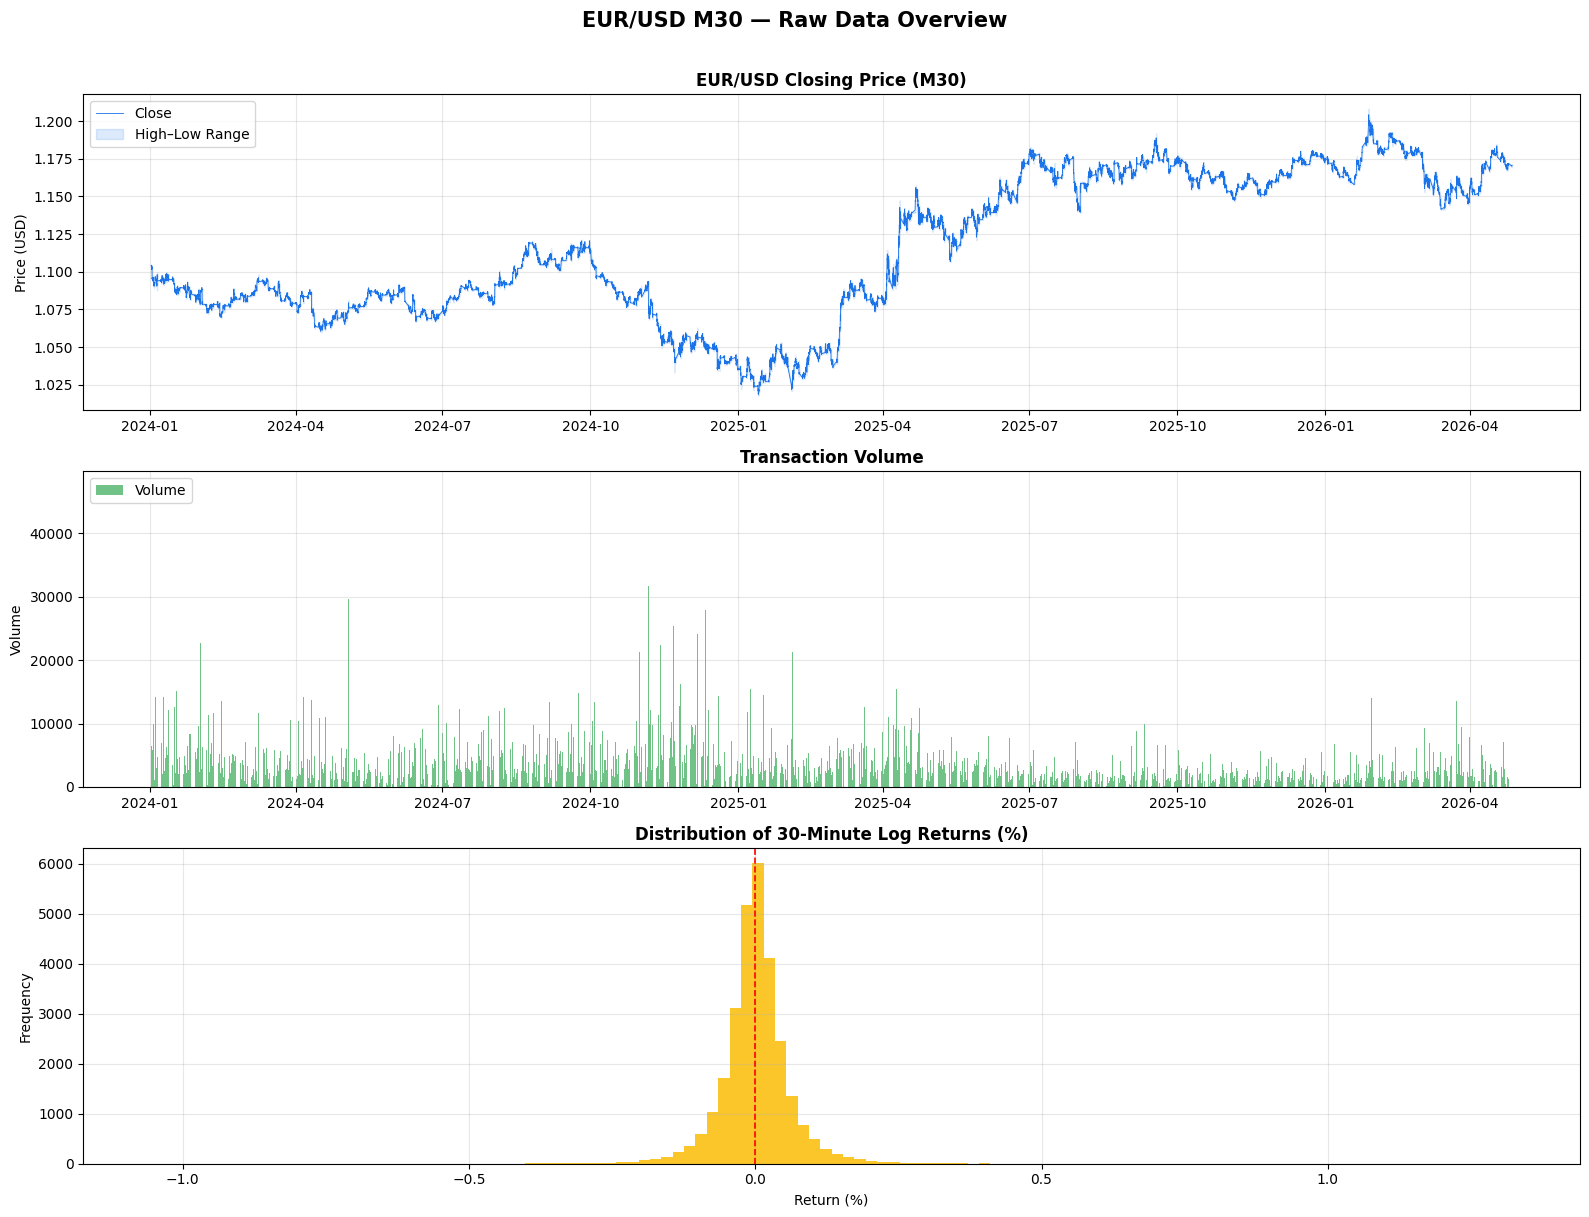

Figure 1 saved.


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('EUR/USD M30 — Raw Data Overview', fontsize=15, fontweight='bold', y=1.01)

#panel 1: OHLC Close Price
axes[0].plot(df.index, df['close'], color='#1a73e8', linewidth=0.6, label='Close')
axes[0].fill_between(df.index, df['low'], df['high'], alpha=0.15, color='#1a73e8', label='High–Low Range')
axes[0].set_title('EUR/USD Closing Price (M30)', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

#panel 2: Volume
axes[1].bar(df.index, df['volume'], color='#34a853', alpha=0.7, width=0.02, label='Volume')
axes[1].set_title('Transaction Volume', fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

#panel 3: Returns distribution
returns = df['close'].pct_change().dropna() * 100
axes[2].hist(returns, bins=120, color='#fbbc04', edgecolor='none', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[2].set_title('Distribution of 30-Minute Log Returns (%)', fontweight='bold')
axes[2].set_xlabel('Return (%)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

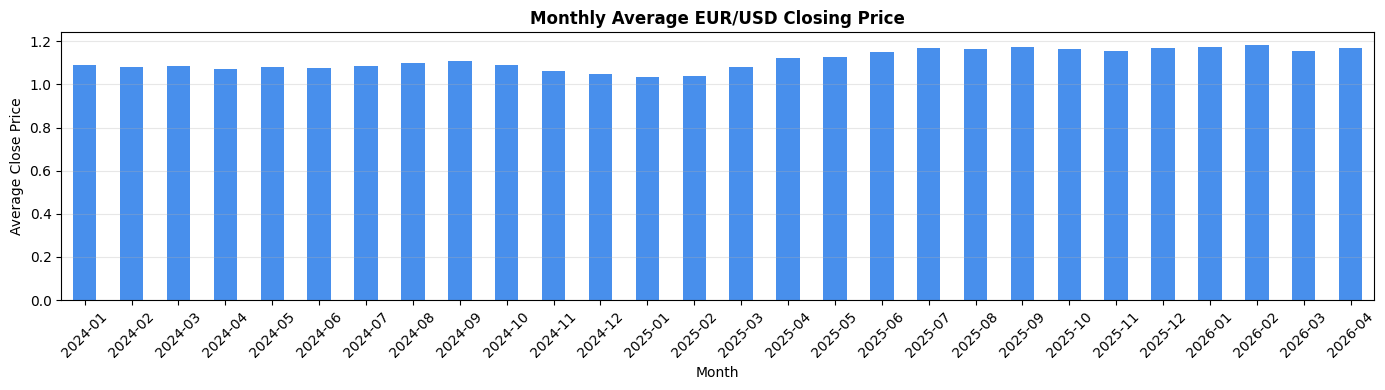

Figure 2 saved.


In [6]:
#monthly average close — seasonality check
df['year_month'] = df.index.to_period('M')
monthly_avg = df.groupby('year_month')['close'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_avg.plot(kind='bar', ax=ax, color='#1a73e8', alpha=0.8, edgecolor='none')
ax.set_title('Monthly Average EUR/USD Closing Price', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Close Price')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_monthly_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 5. Feature Engineering — Technical Indicators & Candlestick Patterns

In [7]:
feat = df[['open', 'high', 'low', 'close', 'volume']].copy()

#trend Indicators
#simple and xponential moving averages
feat['sma_10']  = SMAIndicator(feat['close'], window=10).sma_indicator()
feat['sma_20']  = SMAIndicator(feat['close'], window=20).sma_indicator()
feat['ema_10']  = EMAIndicator(feat['close'], window=10).ema_indicator()
feat['ema_20']  = EMAIndicator(feat['close'], window=20).ema_indicator()

#MACD
macd = MACD(feat['close'], window_slow=26, window_fast=12, window_sign=9)
feat['macd']        = macd.macd()
feat['macd_signal'] = macd.macd_signal()
feat['macd_diff']   = macd.macd_diff()

#momentum indicators
feat['rsi_14'] = RSIIndicator(feat['close'], window=14).rsi()

stoch = StochasticOscillator(feat['high'], feat['low'], feat['close'], window=14)
feat['stoch_k'] = stoch.stoch()
feat['stoch_d'] = stoch.stoch_signal()

#volatility indicators
bb = BollingerBands(feat['close'], window=20, window_dev=2)
feat['bb_upper']  = bb.bollinger_hband()
feat['bb_lower']  = bb.bollinger_lband()
feat['bb_middle'] = bb.bollinger_mavg()
feat['bb_width']  = bb.bollinger_wband()
feat['bb_pct']    = bb.bollinger_pband() #%B position within bands

feat['atr_14'] = AverageTrueRange(feat['high'], feat['low'], feat['close'], window=14).average_true_range()

#volume indicator
feat['obv'] = OnBalanceVolumeIndicator(feat['close'], feat['volume']).on_balance_volume()

#price-derived features
feat['hl_range']   = feat['high'] - feat['low']  #Candle body range
feat['oc_range']   = feat['close'] - feat['open'] #Open-Close delta
feat['log_return'] = np.log(feat['close'] / feat['close'].shift(1))
feat['return_5']   = feat['close'].pct_change(5)  # 5-bar momentum
feat['return_10']  = feat['close'].pct_change(10) # 10-bar momentum

#Candlestick Patterns (binary flags)
#Doji: open ≈ close, small body relative to range
feat['doji'] = (np.abs(feat['oc_range']) < 0.1 * feat['hl_range']).astype(int)

#Bullish Engulfing: current candle fully engulfs previous bearish candle
prev_open  = feat['open'].shift(1)
prev_close = feat['close'].shift(1)
feat['bullish_engulfing'] = (
    (prev_close < prev_open) &
    (feat['close'] > feat['open']) &
    (feat['open'] < prev_close) &
    (feat['close'] > prev_open)
).astype(int)

#Bearish Engulfing
feat['bearish_engulfing'] = (
    (prev_close > prev_open) &
    (feat['close'] < feat['open']) &
    (feat['open'] > prev_close) &
    (feat['close'] < prev_open)
).astype(int)

#Hammer: small body, long lower wick
lower_wick = feat[['open', 'close']].min(axis=1) - feat['low']
upper_wick = feat['high'] - feat[['open', 'close']].max(axis=1)
body       = np.abs(feat['oc_range'])
feat['hammer'] = (
    (lower_wick > 2 * body) &
    (upper_wick < body)
).astype(int)

#Hour of day & day of week (time-of-day seasonality)
feat['hour']       = feat.index.hour
feat['day_of_week'] = feat.index.dayofweek

#Drop helper column
feat.drop(columns=['year_month'], inplace=True, errors='ignore')

#Drop NaNs introduced by rolling indicators
feat.dropna(inplace=True)

print(f'Feature set shape: {feat.shape}')
print(f'Features ({len(feat.columns)}):')
print(list(feat.columns))

Feature set shape: (28812, 33)
Features (33):
['open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_20', 'ema_10', 'ema_20', 'macd', 'macd_signal', 'macd_diff', 'rsi_14', 'stoch_k', 'stoch_d', 'bb_upper', 'bb_lower', 'bb_middle', 'bb_width', 'bb_pct', 'atr_14', 'obv', 'hl_range', 'oc_range', 'log_return', 'return_5', 'return_10', 'doji', 'bullish_engulfing', 'bearish_engulfing', 'hammer', 'hour', 'day_of_week']


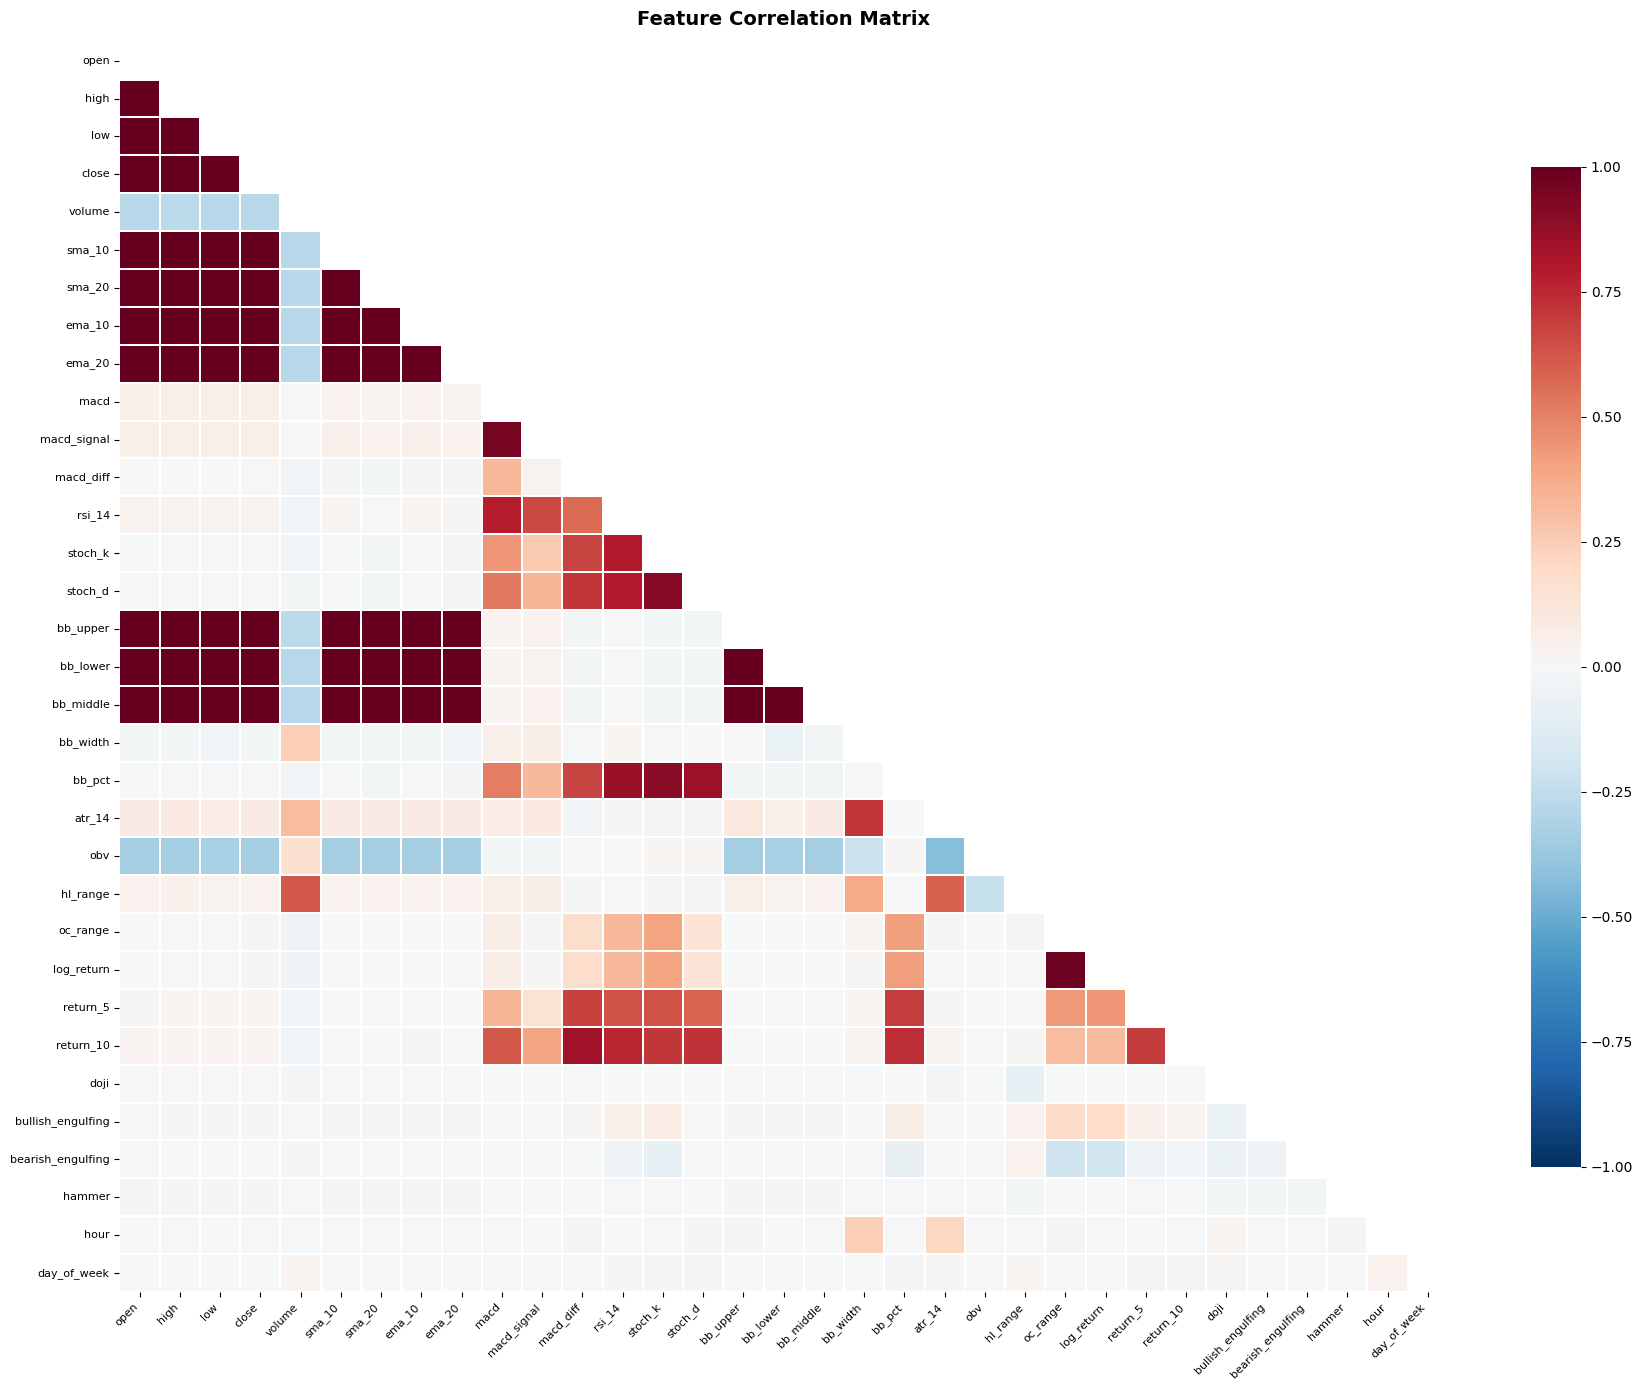

Figure 3 saved.


In [8]:
#Correlation heatmap of all features
fig, ax = plt.subplots(figsize=(18, 14))
corr = feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

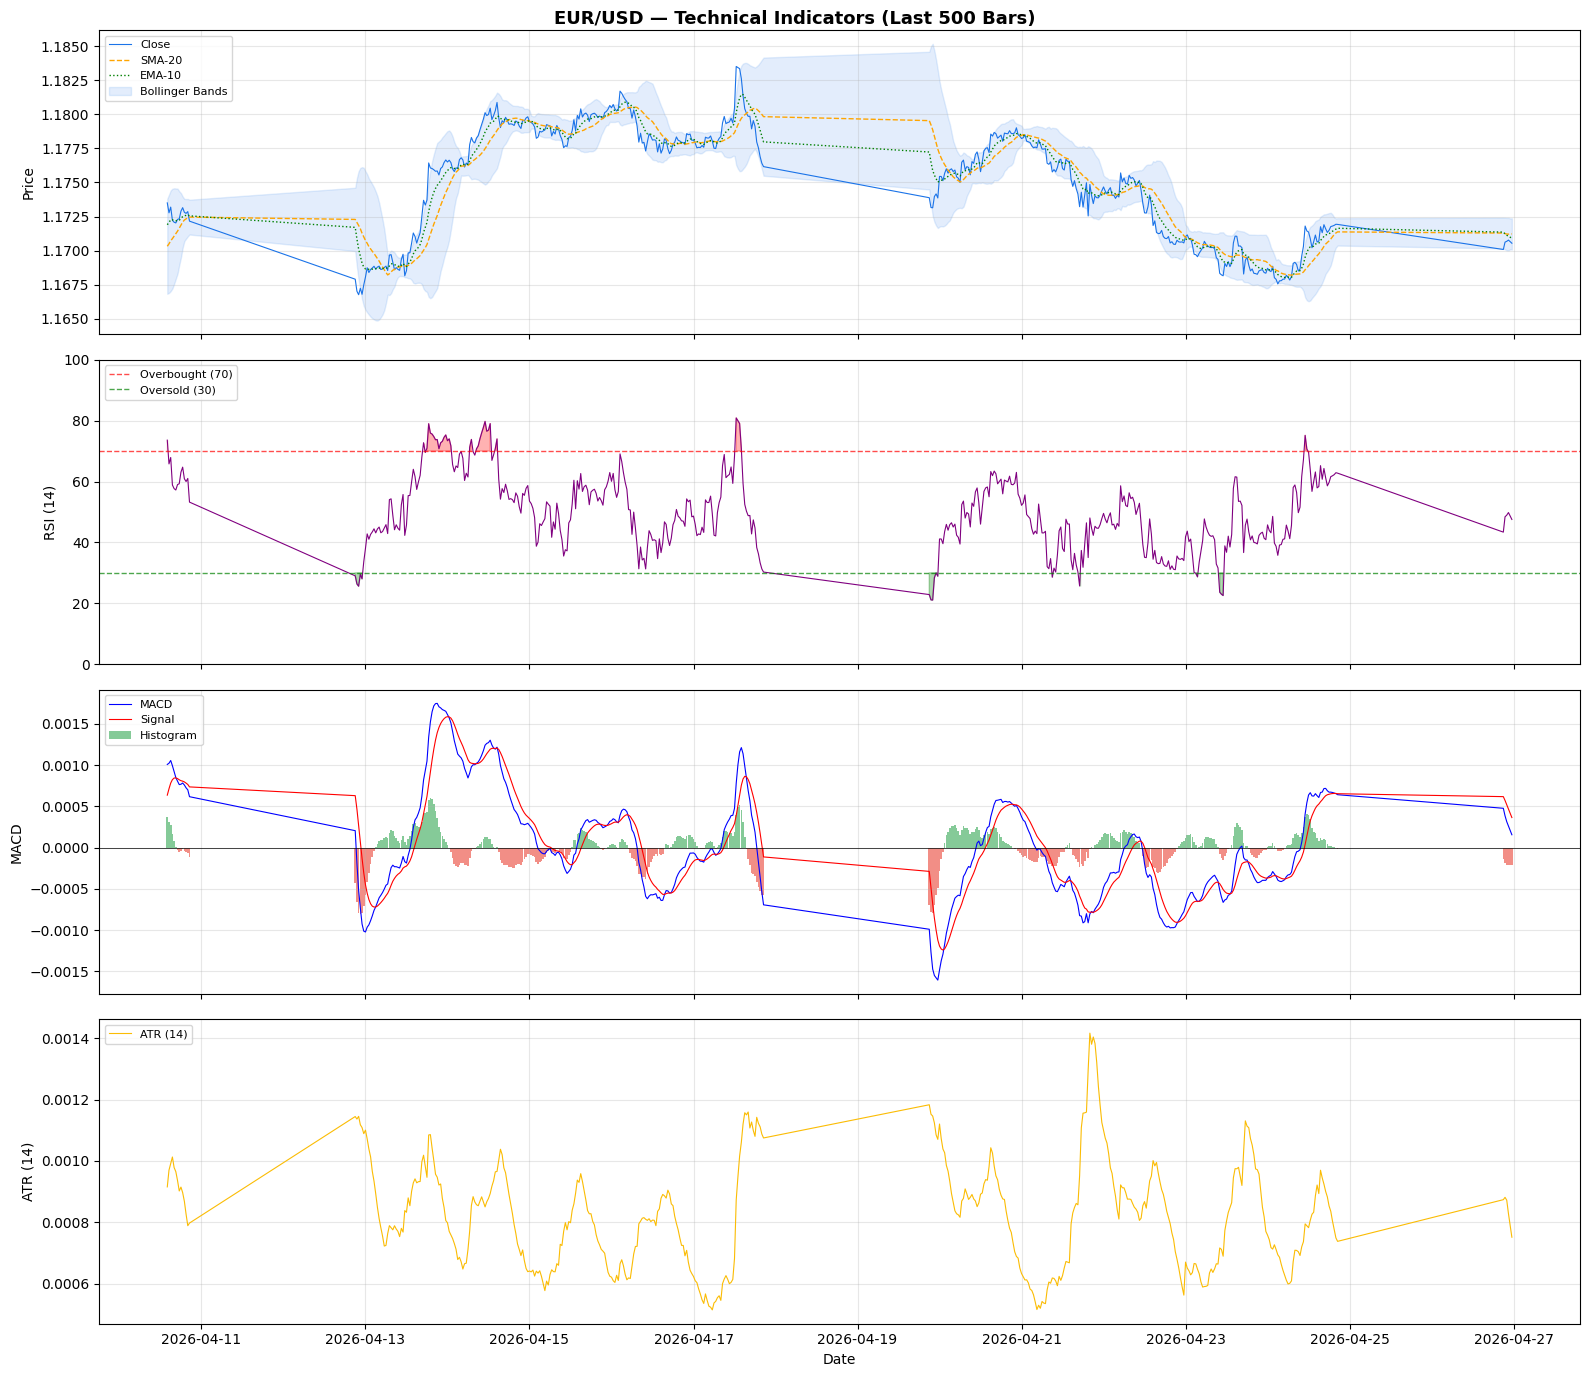

Figure 4 saved.


In [9]:
#Technical indicator overlay plot
sample = feat.iloc[-500:].copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('EUR/USD — Technical Indicators (Last 500 Bars)', fontsize=13, fontweight='bold')

#Price + Bollinger Bands + SMAs
axes[0].plot(sample.index, sample['close'],    color='#1a73e8', lw=0.8, label='Close')
axes[0].plot(sample.index, sample['sma_20'],   color='orange',  lw=1.0, label='SMA-20', linestyle='--')
axes[0].plot(sample.index, sample['ema_10'],   color='green',   lw=1.0, label='EMA-10', linestyle=':')
axes[0].fill_between(sample.index, sample['bb_upper'], sample['bb_lower'],
                     alpha=0.12, color='#1a73e8', label='Bollinger Bands')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

#RSI
axes[1].plot(sample.index, sample['rsi_14'], color='purple', lw=0.8)
axes[1].axhline(70, color='red',   linestyle='--', lw=1, alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', lw=1, alpha=0.7, label='Oversold (30)')
axes[1].fill_between(sample.index, sample['rsi_14'], 70,
                     where=(sample['rsi_14'] >= 70), alpha=0.3, color='red')
axes[1].fill_between(sample.index, sample['rsi_14'], 30,
                     where=(sample['rsi_14'] <= 30), alpha=0.3, color='green')
axes[1].set_ylabel('RSI (14)')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

#MACD
axes[2].plot(sample.index, sample['macd'],        color='blue',  lw=0.8, label='MACD')
axes[2].plot(sample.index, sample['macd_signal'], color='red',   lw=0.8, label='Signal')
axes[2].bar(sample.index,  sample['macd_diff'],
            color=np.where(sample['macd_diff'] >= 0, '#34a853', '#ea4335'),
            alpha=0.6, width=0.02, label='Histogram')
axes[2].axhline(0, color='black', lw=0.5)
axes[2].set_ylabel('MACD')
axes[2].legend(loc='upper left', fontsize=8)
axes[2].grid(True, alpha=0.3)

#ATR
axes[3].plot(sample.index, sample['atr_14'], color='#fbbc04', lw=0.8, label='ATR (14)')
axes[3].set_ylabel('ATR (14)')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', fontsize=8)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 6. Data Preparation for Neural Networks

In [10]:
TARGET_COL   = 'close'
SEQUENCE_LEN = 48
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15

feature_cols = list(feat.columns)
data_vals    = feat[feature_cols].values
target_vals  = feat[[TARGET_COL]].values

n         = len(data_vals)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

x_train_raw = data_vals[:train_end]
x_val_raw   = data_vals[train_end:val_end]
x_test_raw  = data_vals[val_end:]

y_train_raw = target_vals[:train_end]
y_val_raw   = target_vals[train_end:val_end]
y_test_raw  = target_vals[val_end:]

print(f'Train: {len(x_train_raw):,}  Val: {len(x_val_raw):,}  Test: {len(x_test_raw):,}')

Train: 20,168  Val: 4,322  Test: 4,322


In [11]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_sc = scaler_x.fit_transform(x_train_raw)
x_val_sc   = scaler_x.transform(x_val_raw)
x_test_sc  = scaler_x.transform(x_test_raw)

y_train_sc = scaler_y.fit_transform(y_train_raw)
y_val_sc   = scaler_y.transform(y_val_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

In [12]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

x_train, y_train = create_sequences(x_train_sc, y_train_sc, SEQUENCE_LEN)
x_val,   y_val   = create_sequences(x_val_sc,   y_val_sc,   SEQUENCE_LEN)
x_test,  y_test  = create_sequences(x_test_sc,  y_test_sc,  SEQUENCE_LEN)

print(f'Train: {x_train.shape}  Val: {x_val.shape}  Test: {x_test.shape}')

Train: (20120, 48, 33)  Val: (4274, 48, 33)  Test: (4274, 48, 33)


## 7. Model Configuration

In [13]:
INPUT_SHAPE = (x_train.shape[1], x_train.shape[2])

#Fixed hyperparameters
BEST_LR      = 1e-3
BEST_UNITS_1 = 64
BEST_UNITS_2 = 32
BEST_DENSE   = 32
BEST_DROPOUT = 0.2

## 8. Model Architectures

Three architectures are trained and compared:
1. **LSTM** — Long Short-Term Memory
2. **GRU** — Gated Recurrent Unit
3. **CNN-LSTM** — 1D Convolutional feature extractor + LSTM sequence learner


In [14]:
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(filepath=f'best_{model_name}.keras', monitor='val_loss', save_best_only=True, verbose=0)
    ]

EPOCHS     = 50
BATCH_SIZE = 64

In [15]:
def build_lstm(input_shape, units_1=64, units_2=32, dense=32, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units_1, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.LSTM(units_2, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.Dense(dense, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1)
    ], name='LSTM_Model')
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm(INPUT_SHAPE, units_1=BEST_UNITS_1, units_2=BEST_UNITS_2,
                        dense=BEST_DENSE, dropout=BEST_DROPOUT, lr=BEST_LR)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,721 (151.25 KB)

 Trainable params: 38,657 (151.00 KB)

 Non-trainable params: 64 (256.00 B)

In [16]:
print('Training LSTM...')
hist_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks('lstm'),
    verbose=1
)
print('Done.')

Training LSTM...
Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 0.0932 - mae: 0.1630 - val_loss: 0.0955 - val_mae: 0.2843 - learning_rate: 0.0010
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.0207 - mae: 0.0668 - val_loss: 0.0358 - val_mae: 0.1523 - learning_rate: 0.0010
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - loss: 0.0167 - mae: 0.0553 - val_loss: 0.0149 - val_mae: 0.0613 - learning_rate: 0.0010
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - loss: 0.0140 - mae: 0.0481 - val_loss: 0.0097 - val_mae: 0.0134 - learning_rate: 0.0010
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - loss: 0.0118 - mae: 0.0426 - val_loss: 0.0085 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - loss: 0.0100 - mae: 0.0382 - val_loss: 0.0072 - val_mae: 0.0097 - learning_rate: 0.0010
Epoch 7/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.0087 - mae: 0.0364 - val_loss: 0.0062 - val_mae: 0.0105

In [17]:
def build_gru(input_shape, units_1=64, units_2=32, dense=32, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(units_1, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.GRU(units_2, return_sequences=False, kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.Dense(dense, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1)
    ], name='GRU_Model')
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

gru_model = build_gru(INPUT_SHAPE, units_1=BEST_UNITS_1, units_2=BEST_UNITS_2,
                      dense=BEST_DENSE, dropout=BEST_DROPOUT, lr=BEST_LR)
gru_model.summary()

print('\nTraining GRU...')
hist_gru = gru_model.fit(
    x_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks('gru'),
    verbose=1
)
print('Done.')

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48, 64)         │        19,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,633 (115.75 KB)

 Trainable params: 29,569 (115.50 KB)

 Non-trainable params: 64 (256.00 B)


Training GRU...
Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - loss: 0.0991 - mae: 0.1633 - val_loss: 0.0350 - val_mae: 0.1494 - learning_rate: 0.0010
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 0.0194 - mae: 0.0693 - val_loss: 0.0106 - val_mae: 0.0228 - learning_rate: 0.0010
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - loss: 0.0155 - mae: 0.0590 - val_loss: 0.0122 - val_mae: 0.0605 - learning_rate: 0.0010
Epoch 4/50
314/315 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0129 - mae: 0.0522
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
315/315 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - loss: 0.0124 - mae: 0.0521 - val_loss: 0.0118 - val_mae: 0.0679 - learning_rate: 0.0010
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - loss: 0.0104 - mae: 0.0458 - val_loss: 0.0112 - val_mae: 0.0673 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Done.


In [18]:
def build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=64,
                   dense=32, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same'),
        layers.Conv1D(filters=filters // 2, kernel_size=kernel_size, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(dropout / 2),
        layers.LSTM(lstm_units, return_sequences=True, kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(dropout),
        layers.LSTM(lstm_units // 2, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(dense, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(1)
    ], name='CNN_LSTM_Model')
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

cnn_lstm_model = build_cnn_lstm(INPUT_SHAPE, filters=64, kernel_size=3,
                                lstm_units=BEST_UNITS_1, dense=BEST_DENSE,
                                dropout=BEST_DROPOUT, lr=BEST_LR)
cnn_lstm_model.summary()

print('\nTraining CNN-LSTM...')
hist_cnn_lstm = cnn_lstm_model.fit(
    x_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=get_callbacks('cnn_lstm'),
    verbose=1
)
print('Done.')

Model: "CNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 48, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,041 (199.38 KB)

 Trainable params: 50,977 (199.13 KB)

 Non-trainable params: 64 (256.00 B)


Training CNN-LSTM...
Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 0.0362 - mae: 0.0914 - val_loss: 0.1400 - val_mae: 0.3677 - learning_rate: 0.0010
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.0050 - mae: 0.0368 - val_loss: 0.0492 - val_mae: 0.2154 - learning_rate: 0.0010
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - loss: 0.0039 - mae: 0.0340 - val_loss: 0.0032 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.0033 - mae: 0.0325 - val_loss: 0.0025 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0028 - mae: 0.0314 - val_loss: 0.0014 - val_mae: 0.0143 - learning_rate: 0.0010
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0026 - mae: 0.0309 - val_loss: 0.0049 - val_mae: 0.0616 - learning_rate: 0.0010
Epoch 7/50
314/315 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023 - mae: 0.0297
Epoch 7: ReduceLROnPlateau reduc

## 9. Training History Visualisation

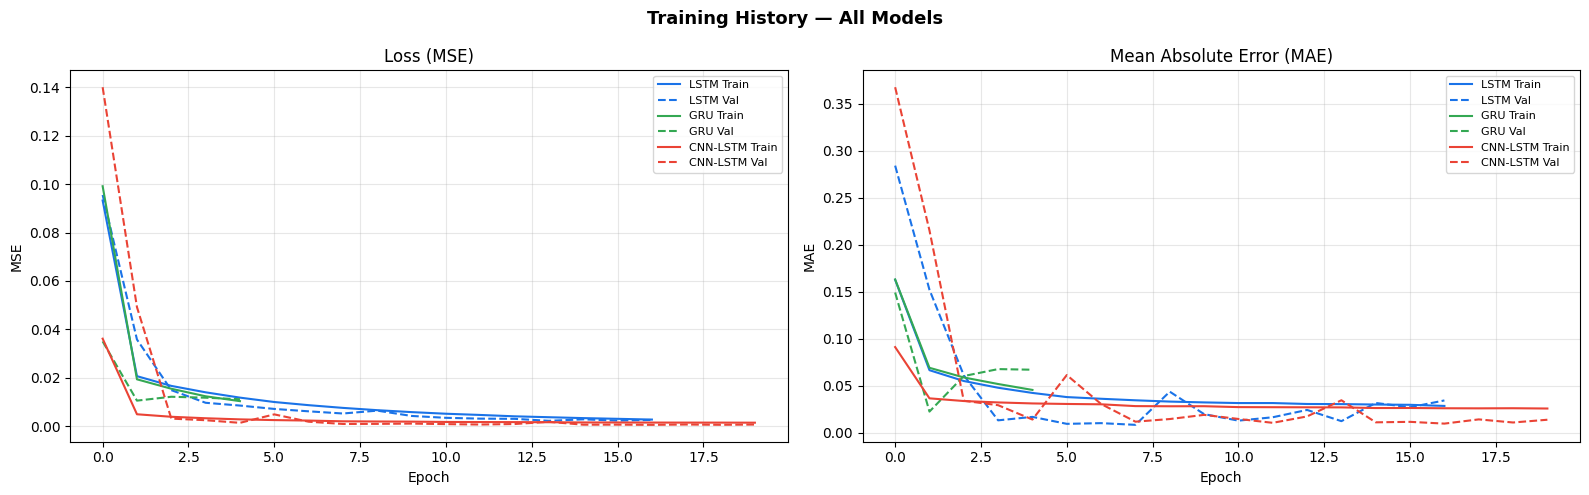

Figure 5 saved.


In [19]:
def plot_training_history(histories, names, colors):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History — All Models', fontsize=13, fontweight='bold')

    for hist, name, color in zip(histories, names, colors):
        axes[0].plot(hist.history['loss'],     color=color, lw=1.5,
                     label=f'{name} Train')
        axes[0].plot(hist.history['val_loss'], color=color, lw=1.5,
                     linestyle='--', label=f'{name} Val')

        axes[1].plot(hist.history['mae'],      color=color, lw=1.5,
                     label=f'{name} Train')
        axes[1].plot(hist.history['val_mae'],  color=color, lw=1.5,
                     linestyle='--', label=f'{name} Val')

    axes[0].set_title('Loss (MSE)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Mean Absolute Error (MAE)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig5_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure 5 saved.')

plot_training_history(
    [hist_lstm, hist_gru, hist_cnn_lstm],
    ['LSTM', 'GRU', 'CNN-LSTM'],
    ['#1a73e8', '#34a853', '#ea4335']
)

## 10. Evaluation — Error Metrics on Test Set

In [22]:
def evaluate_model(model, X_test, y_test_sc, scaler_y, model_name):
    y_pred_sc = model.predict(x_test, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_sc)
    y_true = scaler_y.inverse_transform(y_test_sc)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    print(f'\n── {model_name} ──────────────────────')
    print(f'  MSE:  {mse:.8f}')
    print(f'  RMSE: {rmse:.6f}')
    print(f'  MAE:  {mae:.6f}')
    print(f'  MAPE: {mape:.4f}%')
    print(f'  R²:   {r2:.6f}')

    return {
        'Model': model_name, 'MSE': round(mse, 8), 'RMSE': round(rmse, 6),
        'MAE': round(mae, 6), 'MAPE (%)': round(mape, 4), 'R²': round(r2, 6)
    }, y_pred.flatten(), y_true.flatten()


metrics_lstm,     pred_lstm,     true_vals = evaluate_model(lstm_model,     x_test, y_test, scaler_y, 'LSTM')
metrics_gru,      pred_gru,      _         = evaluate_model(gru_model,      x_test, y_test, scaler_y, 'GRU')
metrics_cnn_lstm, pred_cnn_lstm, _         = evaluate_model(cnn_lstm_model, x_test, y_test, scaler_y, 'CNN-LSTM')

results_df = pd.DataFrame([metrics_lstm, metrics_gru, metrics_cnn_lstm]).set_index('Model')
print(results_df.to_string())
results_df


── LSTM ──────────────────────
  MSE:  0.00001267
  RMSE: 0.003559
  MAE:  0.003014
  MAPE: 0.2561%
  R²:   0.918216

── GRU ──────────────────────
  MSE:  0.00001856
  RMSE: 0.004308
  MAE:  0.003407
  MAPE: 0.2921%
  R²:   0.880199

── CNN-LSTM ──────────────────────
  MSE:  0.00001413
  RMSE: 0.003759
  MAE:  0.002768
  MAPE: 0.2352%
  R²:   0.908772
               MSE      RMSE       MAE  MAPE (%)        R²
Model                                                     
LSTM      0.000013  0.003559  0.003014    0.2561  0.918216
GRU       0.000019  0.004308  0.003407    0.2921  0.880199
CNN-LSTM  0.000014  0.003759  0.002768    0.2352  0.908772


,MSE,RMSE,MAE,MAPE (%),R²
Model,,,,,
LSTM,0.000013,0.003559,0.003014,0.2561,0.918216
GRU,0.000019,0.004308,0.003407,0.2921,0.880199
CNN-LSTM,0.000014,0.003759,0.002768,0.2352,0.908772


## 11. Advanced Visualisation of Predictions

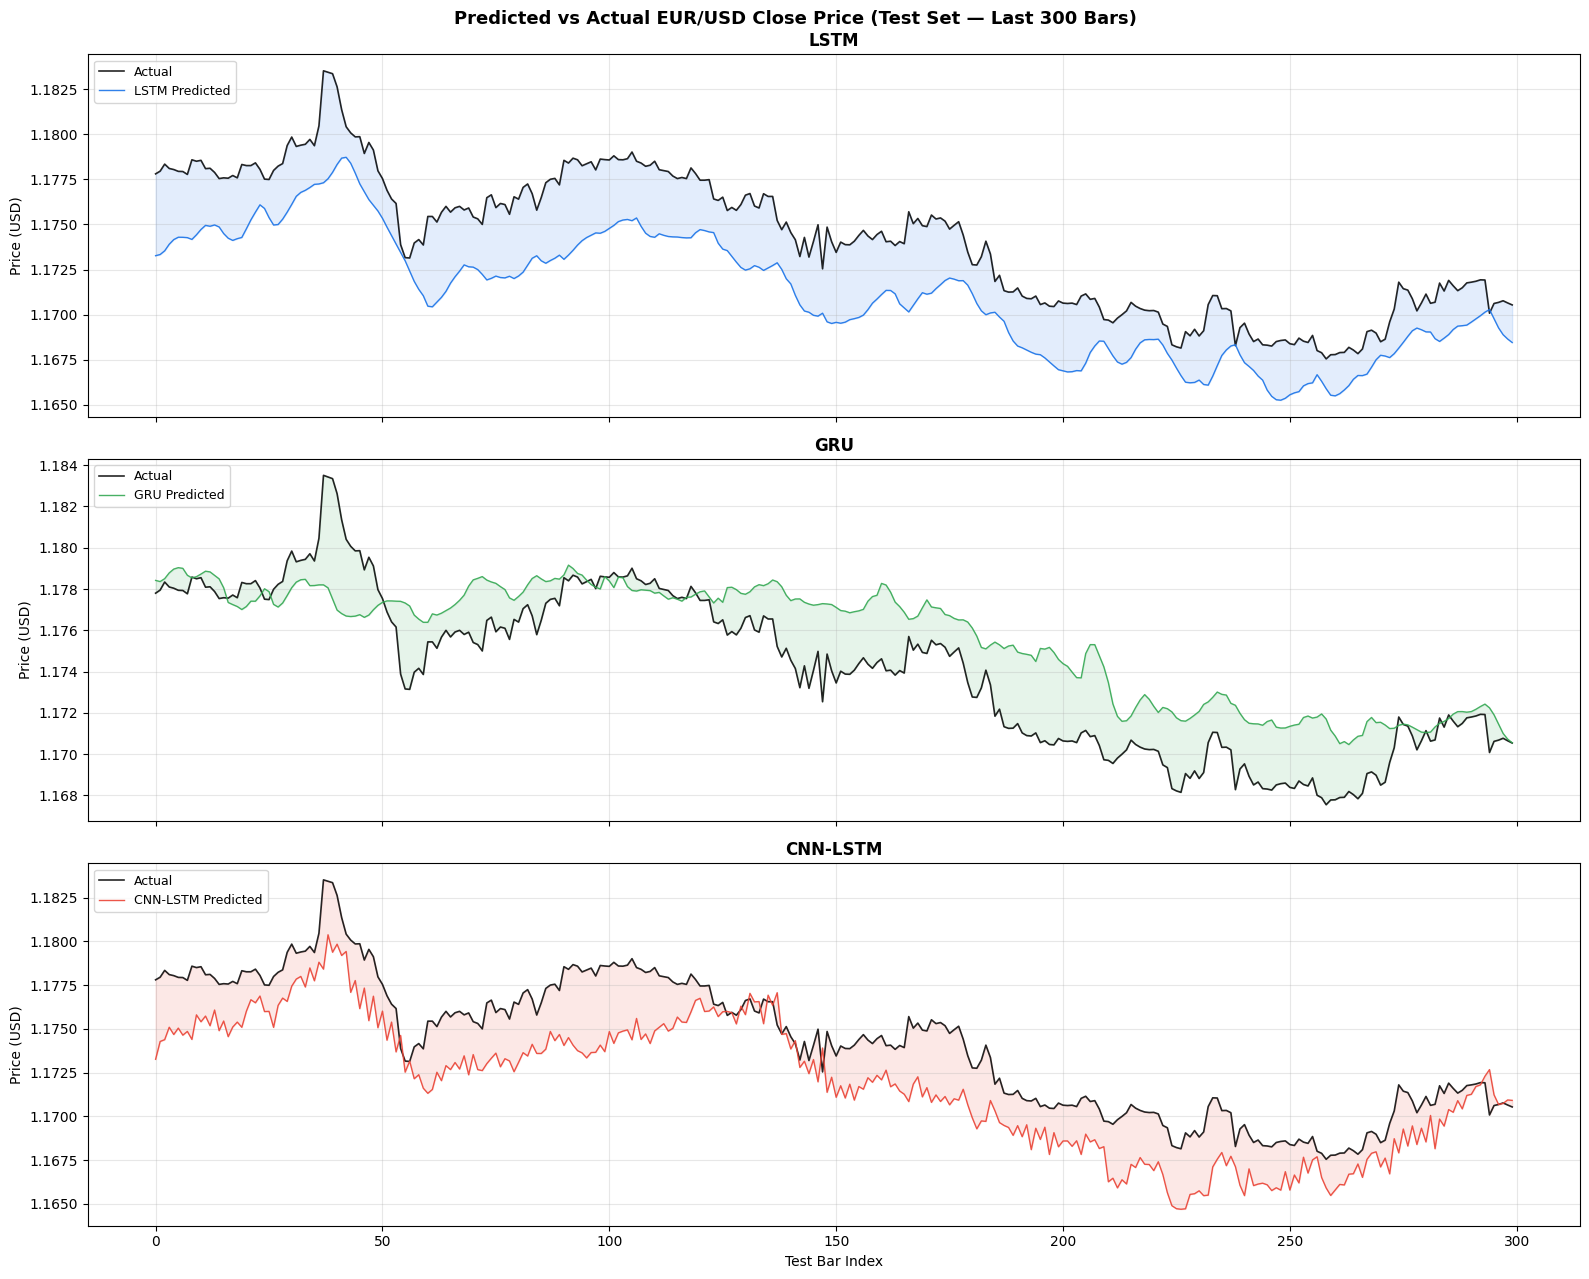

Figure 6 saved.


In [23]:
#Predicted vs Actual — all three models
PLOT_N = 300   #last N test samples for clarity

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle('Predicted vs Actual EUR/USD Close Price (Test Set — Last 300 Bars)',
             fontsize=13, fontweight='bold')

preds   = [pred_lstm, pred_gru, pred_cnn_lstm]
names   = ['LSTM', 'GRU', 'CNN-LSTM']
colors  = ['#1a73e8', '#34a853', '#ea4335']

for ax, pred, name, color in zip(axes, preds, names, colors):
    ax.plot(true_vals[-PLOT_N:], color='black',  lw=1.2,  label='Actual',    alpha=0.85)
    ax.plot(pred[-PLOT_N:],      color=color,    lw=1.0,  label=f'{name} Predicted', alpha=0.9)
    ax.fill_between(
        range(PLOT_N),
        true_vals[-PLOT_N:], pred[-PLOT_N:],
        alpha=0.12, color=color
    )
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Test Bar Index')
plt.tight_layout()
plt.savefig('fig6_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

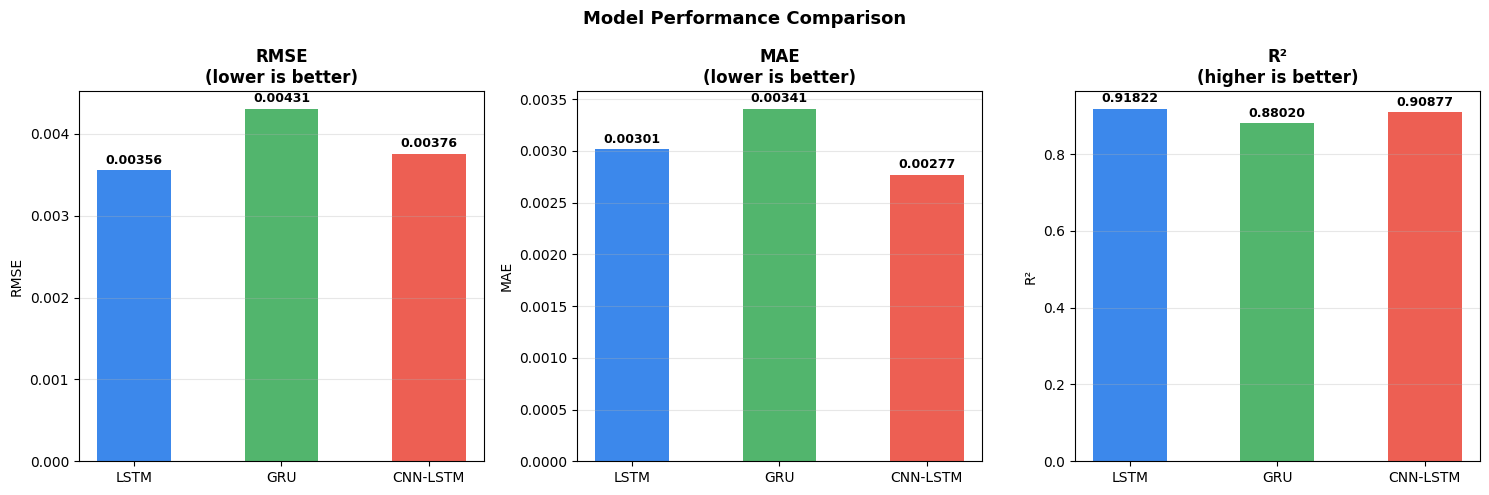

Figure 7 saved.


In [24]:
#Metrics bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

metric_pairs = [('RMSE', 'lower is better'), ('MAE', 'lower is better'), ('R²', 'higher is better')]
bar_colors   = ['#1a73e8', '#34a853', '#ea4335']
model_names  = results_df.index.tolist()

for ax, (metric, note) in zip(axes, metric_pairs):
    vals = results_df[metric].values
    bars = ax.bar(model_names, vals, color=bar_colors, alpha=0.85, edgecolor='none', width=0.5)
    ax.set_title(f'{metric}\n({note})', fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

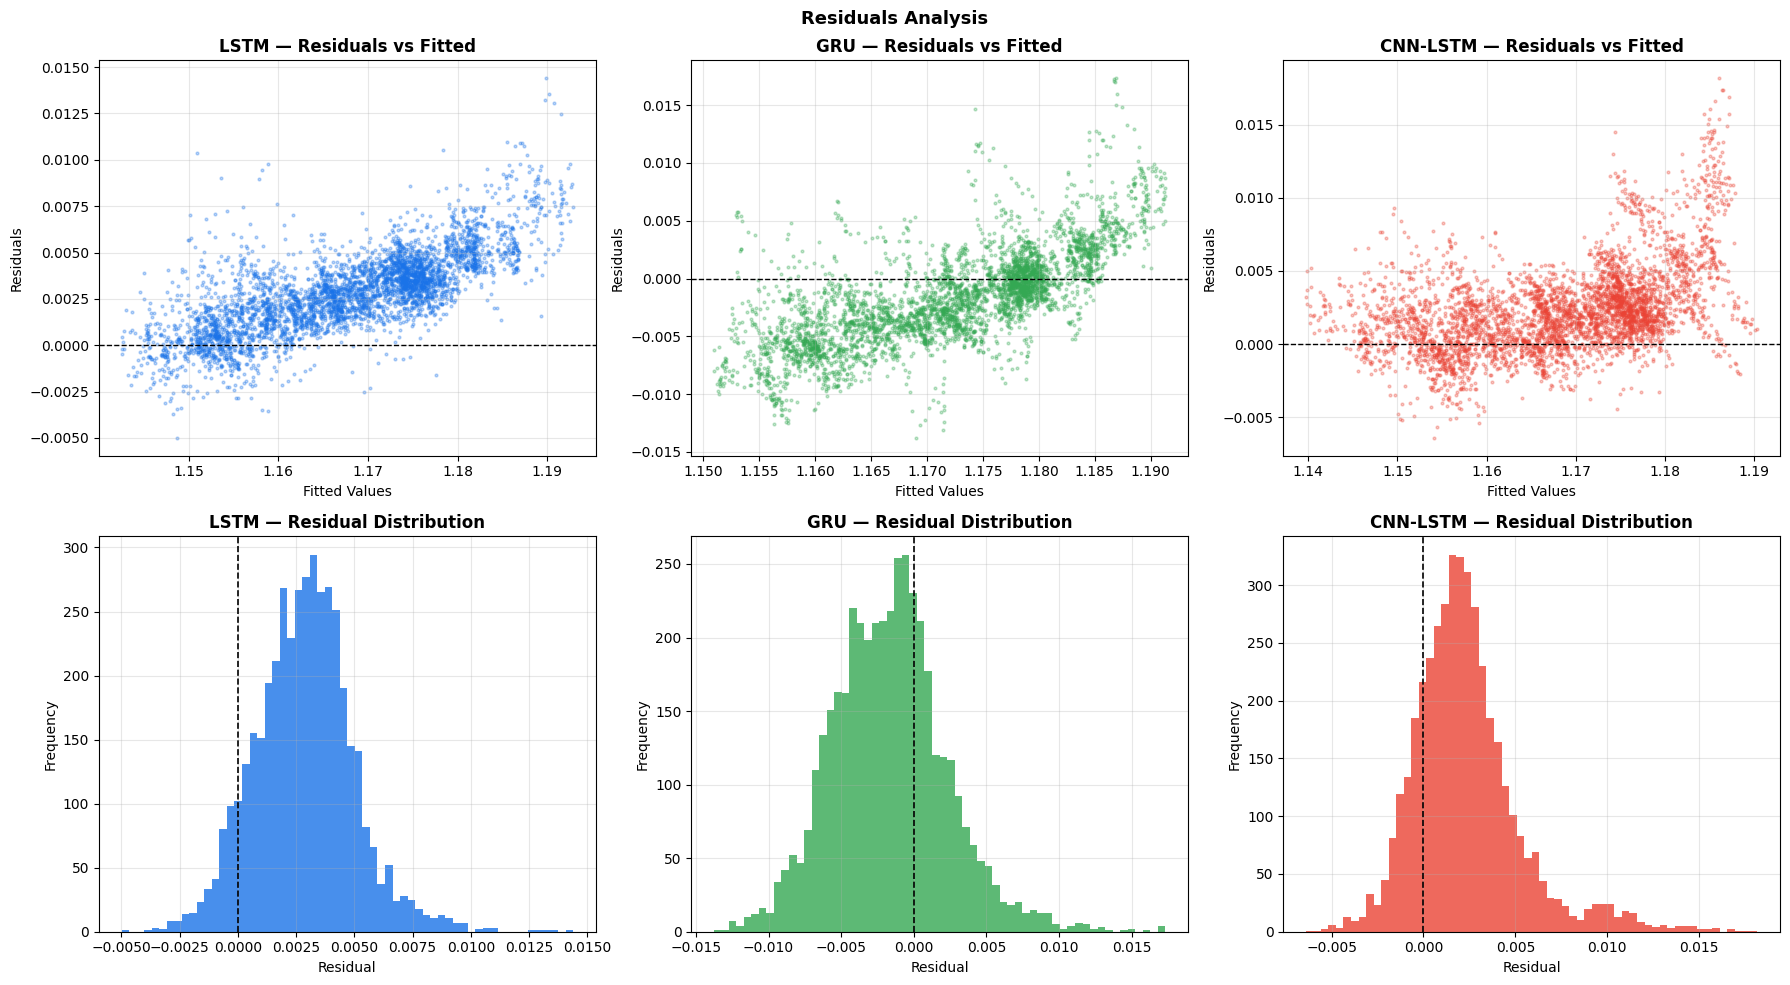

Figure 8 saved.


In [25]:
#Residuals analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residuals Analysis', fontsize=13, fontweight='bold')

all_preds  = [pred_lstm, pred_gru, pred_cnn_lstm]
model_names = ['LSTM', 'GRU', 'CNN-LSTM']
colors      = ['#1a73e8', '#34a853', '#ea4335']

for col, (pred, name, color) in enumerate(zip(all_preds, model_names, colors)):
    residuals = true_vals - pred

    #Row 0: residual scatter
    axes[0, col].scatter(pred, residuals, alpha=0.3, s=4, color=color)
    axes[0, col].axhline(0, color='black', lw=1, linestyle='--')
    axes[0, col].set_title(f'{name} — Residuals vs Fitted', fontweight='bold')
    axes[0, col].set_xlabel('Fitted Values')
    axes[0, col].set_ylabel('Residuals')
    axes[0, col].grid(True, alpha=0.3)

    #Row 1: residual histogram
    axes[1, col].hist(residuals, bins=60, color=color, alpha=0.8, edgecolor='none')
    axes[1, col].axvline(0, color='black', lw=1.2, linestyle='--')
    axes[1, col].set_title(f'{name} — Residual Distribution', fontweight='bold')
    axes[1, col].set_xlabel('Residual')
    axes[1, col].set_ylabel('Frequency')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

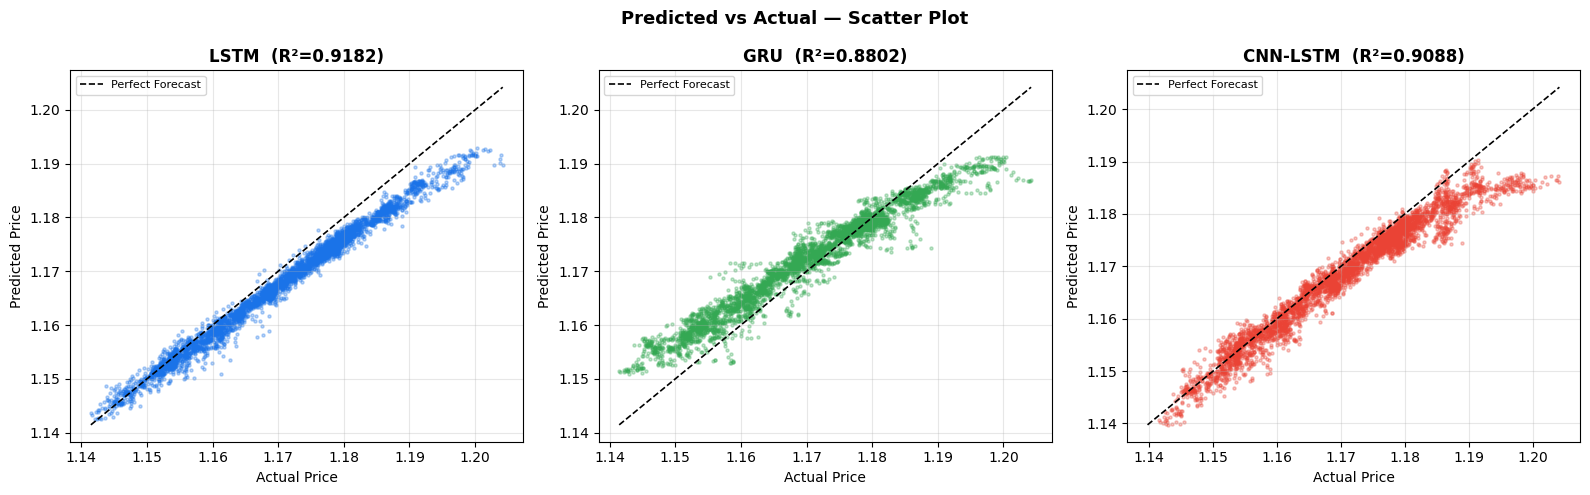

Figure 9 saved.


In [26]:
#Scatter: Predicted vs Actual (all models)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Predicted vs Actual — Scatter Plot', fontsize=13, fontweight='bold')

for ax, pred, name, color in zip(axes, all_preds, model_names, colors):
    ax.scatter(true_vals, pred, alpha=0.3, s=5, color=color)
    lims = [min(true_vals.min(), pred.min()), max(true_vals.max(), pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect Forecast')
    ax.set_title(f'{name}  (R²={results_df.loc[name, "R²"]:.4f})', fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

## 12. Summary & Export

In [27]:
#Final summary table
print('=' * 60)
print('  FINAL MODEL COMPARISON — EUR/USD M30 FORECASTING')
print('=' * 60)
print(results_df.to_string())
print('=' * 60)

best_model_name = results_df['RMSE'].idxmin()
print(f'\n Best model by RMSE: {best_model_name}')
print(f'   RMSE  = {results_df.loc[best_model_name, "RMSE"]}')
print(f'   MAE   = {results_df.loc[best_model_name, "MAE"]}')
print(f'   MAPE  = {results_df.loc[best_model_name, "MAPE (%)"]:.4f}%')
print(f'   R²    = {results_df.loc[best_model_name, "R²"]}')

#Export results to CSV
results_df.to_csv('model_results.csv')
print('\nResults saved to model_results.csv')

figures = [
    'fig1_eda_overview.png', 'fig2_monthly_avg.png',
    'fig3_correlation_heatmap.png', 'fig4_technical_indicators.png',
    'fig5_training_history.png', 'fig6_predictions_vs_actual.png',
    'fig7_metrics_comparison.png', 'fig8_residuals.png',
    'fig9_scatter_pred_vs_actual.png'
]

print('\nGenerated figures:')
for i, f in enumerate(figures, 1):
    exists = 'Saved' if os.path.exists(f) else 'Not Saved'
    print(f'  {exists} Figure {i}: {f}')

  FINAL MODEL COMPARISON — EUR/USD M30 FORECASTING
               MSE      RMSE       MAE  MAPE (%)        R²
Model                                                     
LSTM      0.000013  0.003559  0.003014    0.2561  0.918216
GRU       0.000019  0.004308  0.003407    0.2921  0.880199
CNN-LSTM  0.000014  0.003759  0.002768    0.2352  0.908772

 Best model by RMSE: LSTM
   RMSE  = 0.003559
   MAE   = 0.003014
   MAPE  = 0.2561%
   R²    = 0.918216

Results saved to model_results.csv

Generated figures:
  Saved Figure 1: fig1_eda_overview.png
  Saved Figure 2: fig2_monthly_avg.png
  Saved Figure 3: fig3_correlation_heatmap.png
  Saved Figure 4: fig4_technical_indicators.png
  Saved Figure 5: fig5_training_history.png
  Saved Figure 6: fig6_predictions_vs_actual.png
  Saved Figure 7: fig7_metrics_comparison.png
  Saved Figure 8: fig8_residuals.png
  Saved Figure 9: fig9_scatter_pred_vs_actual.png
